## Building Chatbot with Multiple Tools Using LangGraph

#### Aim:
Create a chatbot with tool capabilities from ```Arxiv```, ```Wikipedia Search``` and some other functions.

In [1]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper

In [2]:
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv)

In [3]:
arxiv.name

'arxiv'

In [4]:
arxiv.invoke("Attention is all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [6]:
api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=500)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name

'wikipedia'

In [7]:
wiki.invoke("What is Machine Learning?")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalise to unseen data, and thus perform tasks without explicit instructions. Within a subdiscipline in machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.\nML fi'

In [8]:
import os 
from dotenv import load_dotenv
load_dotenv()

True

In [10]:
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [11]:
from langchain_community.tools.tavily_search import TavilySearchResults
tavily = TavilySearchResults()

C:\Users\Karan\AppData\Local\Temp\ipykernel_30464\1535493036.py:2: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [13]:
tavily.invoke("Provide me the recent news about Esports in India")

[{'title': "India's Gaming Market Continues Rapid Expansion | GAM3S.GG",
  'url': 'https://gam3s.gg/news/india-gaming-market-in-2025/',
  'content': '## Competitive Gaming Gains Wider Reach\n\nEsports engagement continues to grow alongside the broader market. Niko Partners reports that 60% of Indian gamers interact with esports in some form, whether through playing competitive games, watching tournaments, or participating in organized competitions. This level of engagement highlights esports as a mainstream part of gaming culture rather than a niche interest. [...] While the player base is massive, monetization is still developing. The report indicates that 26.5% of Indian gamers spend money in games, translating to roughly 126 million paying players. This figure highlights both the scale of current revenue and the long-term potential for growth as payment systems, pricing strategies, and localized content improve. [...] Looking ahead, Niko Partners projects the Indian games market wil

In [15]:
### Combine all the tools in the list

tools = [arxiv,wiki, tavily]

In [18]:
## Initialize the LLM model

from langchain_groq import ChatGroq
llm = ChatGroq(model="llama-3.1-8b-instant")
llm_with_tools = llm.bind_tools(tools)

In [21]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage
llm_with_tools.invoke([HumanMessage(content=f"What is the recent news about Esports in India? Specifically Valorant")])

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'g1q23q4gy', 'function': {'arguments': '{"query":"Valorant esports news India"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 561, 'total_tokens': 583, 'completion_time': 0.032609487, 'completion_tokens_details': None, 'prompt_time': 0.031508037, 'prompt_tokens_details': None, 'queue_time': 0.089208405, 'total_time': 0.064117524}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--2dee35cf-c500-4c98-877f-d87d7fbeba91-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'Valorant esports news India'}, 'id': 'g1q23q4gy', 'type': 'tool_call'}], usage_metadata={'input_tokens': 561, 'output_tokens': 22, 'total_tokens': 583})

In [22]:
llm_with_tools.invoke([HumanMessage(content=f"What is the recent news about Esports in India? Specifically Valorant")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'Valorant Esports news India'},
  'id': 'xrs2c96p5',
  'type': 'tool_call'}]

### Entire ChatBot With LangGraph

In [23]:
## State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages:Annotated[list[AnyMessage], add_messages]

In [25]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


## Build graph

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)

builder.add_edge("tools", END)

In [26]:
graph = builder.compile()

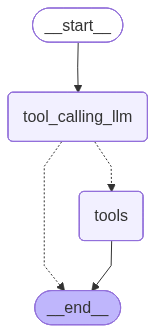

In [27]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [42]:
messages = graph.invoke({"messages": [HumanMessage(content="What is Attention is all you need?")]})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is Attention is all you need?
================================== Ai Message ==================================
Tool Calls:
  arxiv (7aysg4yds)
 Call ID: 7aysg4yds
  Args:
    query: Attention is all you need
================================= Tool Message =================================
Name: arxiv

Published: 2021-05-06
Title: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet
Authors: Luke Melas-Kyriazi
Summary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi


In [43]:
messages = graph.invoke({"messages": [HumanMessage(content="Top 10 recent AI news.")]})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Top 10 recent AI news.
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (8eb4fdtx2)
 Call ID: 8eb4fdtx2
  Args:
    query: Top 10 recent AI news
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "AI News | October 4–10, 2025: Top 10 AI Developments ...", "url": "https://medium.com/@CherryZhouTech/ai-news-october-4-10-2025-top-10-ai-developments-you-cant-miss-this-week-e13a5a3d0461", "content": "OpenAI has officially released the GPT-5 Pro API to all developers, positioning it as its most powerful model yet. Designed for complex tasks like scientific research and legal analysis, it features a massive 400,000-token context window — capable of processing around 300,000 words — and supports both text and image inputs. [...] Sign up\n\nSign in\n\nSign up\n\nSign i

In [45]:
messages = graph.invoke({"messages": [HumanMessage(content="What is Machine Learning?")]})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is Machine Learning?
================================== Ai Message ==================================
Tool Calls:
  wikipedia (tgqc2ncff)
 Call ID: tgqc2ncff
  Args:
    query: Machine Learning
================================= Tool Message =================================
Name: wikipedia

Page: Machine learning
Summary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalise to unseen data, and thus perform tasks without explicit instructions. Within a subdiscipline in machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.
ML fi
